<a href="https://colab.research.google.com/github/Elsacred02/Progetto_AML_2025_2026/blob/main/Codice_progetto_AML_ResNet_2025_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import image_dataset_from_directory

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# ResNet50 + preprocessing specifico
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

BATCH_SIZE = 16
IMG_SIZE = (224, 224)
SEED = 123


In [2]:
# Monta dataset da google drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/sea_animals"
# os.listdir(DATA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


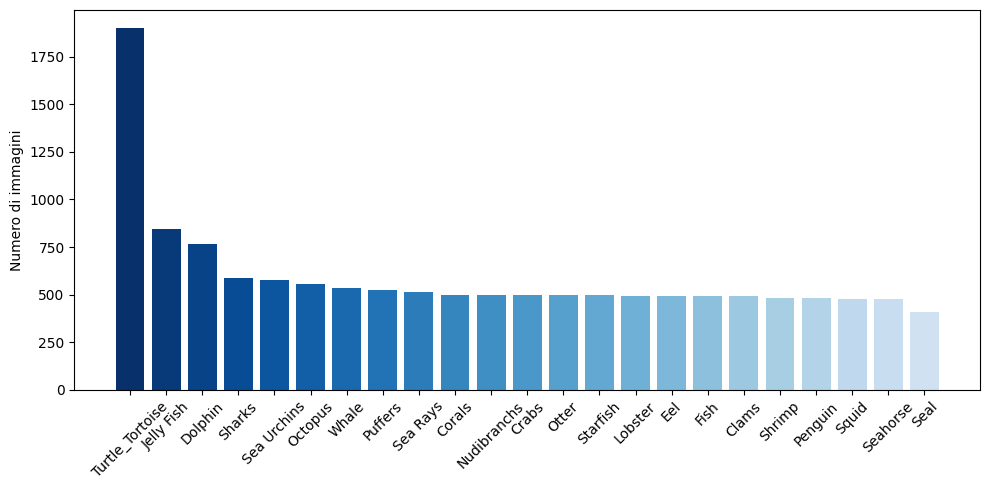

In [3]:
# Controllo bilanciamento dataset

dict_targets_NElements = {}

for directory in os.listdir(DATA_DIR):
    dict_targets_NElements[directory] = len(os.listdir(os.path.join(DATA_DIR, directory)))

dict_targets_NElements = dict(sorted(dict_targets_NElements.items(), key=lambda x: x[1], reverse=True))

colors = plt.cm.Blues(np.linspace(1, 0.2, len(dict_targets_NElements)))

plt.figure(figsize=(10, 5))
plt.bar(dict_targets_NElements.keys(), dict_targets_NElements.values(), color=colors)
plt.xticks(rotation=45)
plt.ylabel("Numero di immagini")
plt.tight_layout()
plt.show()


In [4]:
# Class weights (dataset sbilanciato)

num_classes = len(dict_targets_NElements)
print(f"Numero di classi: {num_classes}")

all_labels = []
class_names_ordered = sorted(dict_targets_NElements.keys())

for idx, class_name in enumerate(class_names_ordered):
    num_samples = dict_targets_NElements[class_name]
    all_labels.extend([idx] * num_samples)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_classes),
    y=all_labels
)

class_weights = dict(enumerate(class_weights_array))

print("\nClass Weights calcolati:")
for class_idx, class_name in enumerate(class_names_ordered):
    print(f"  {class_name}: {class_weights[class_idx]:.4f}")


Numero di classi: 23

Class Weights calcolati:
  Clams: 1.2017
  Corals: 1.1849
  Crabs: 1.1873
  Dolphin: 0.7699
  Eel: 1.1969
  Fish: 1.1969
  Jelly Fish: 0.7005
  Lobster: 1.1945
  Nudibranchs: 1.1849
  Octopus: 1.0596
  Otter: 1.1873
  Penguin: 1.2292
  Puffers: 1.1241
  Sea Rays: 1.1526
  Sea Urchins: 1.0265
  Seahorse: 1.2395
  Seal: 1.4386
  Sharks: 1.0107
  Shrimp: 1.2267
  Squid: 1.2369
  Starfish: 1.1897
  Turtle_Tortoise: 0.3112
  Whale: 1.1072


In [5]:
# Suddivisione dataset (train/val/test)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_test_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take(val_test_batches // 2)
test_ds = val_test_ds.skip(val_test_batches // 2)

class_names = train_ds.class_names
print("Class names (ordine Keras):", class_names)


Found 13599 files belonging to 23 classes.
Using 10880 files for training.
Found 13599 files belonging to 23 classes.
Using 2719 files for validation.
Class names (ordine Keras): ['Clams', 'Corals', 'Crabs', 'Dolphin', 'Eel', 'Fish', 'Jelly Fish', 'Lobster', 'Nudibranchs', 'Octopus', 'Otter', 'Penguin', 'Puffers', 'Sea Rays', 'Sea Urchins', 'Seahorse', 'Seal', 'Sharks', 'Shrimp', 'Squid', 'Starfish', 'Turtle_Tortoise', 'Whale']


In [6]:
# Preprocessing ResNet
train_ds_RN = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds_RN   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds_RN  = test_ds.map(lambda x, y: (preprocess_input(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds_RN = train_ds_RN.shuffle(100).prefetch(buffer_size=AUTOTUNE)
val_ds_RN   = val_ds_RN.prefetch(buffer_size=AUTOTUNE)
test_ds_RN  = test_ds_RN.prefetch(buffer_size=AUTOTUNE)


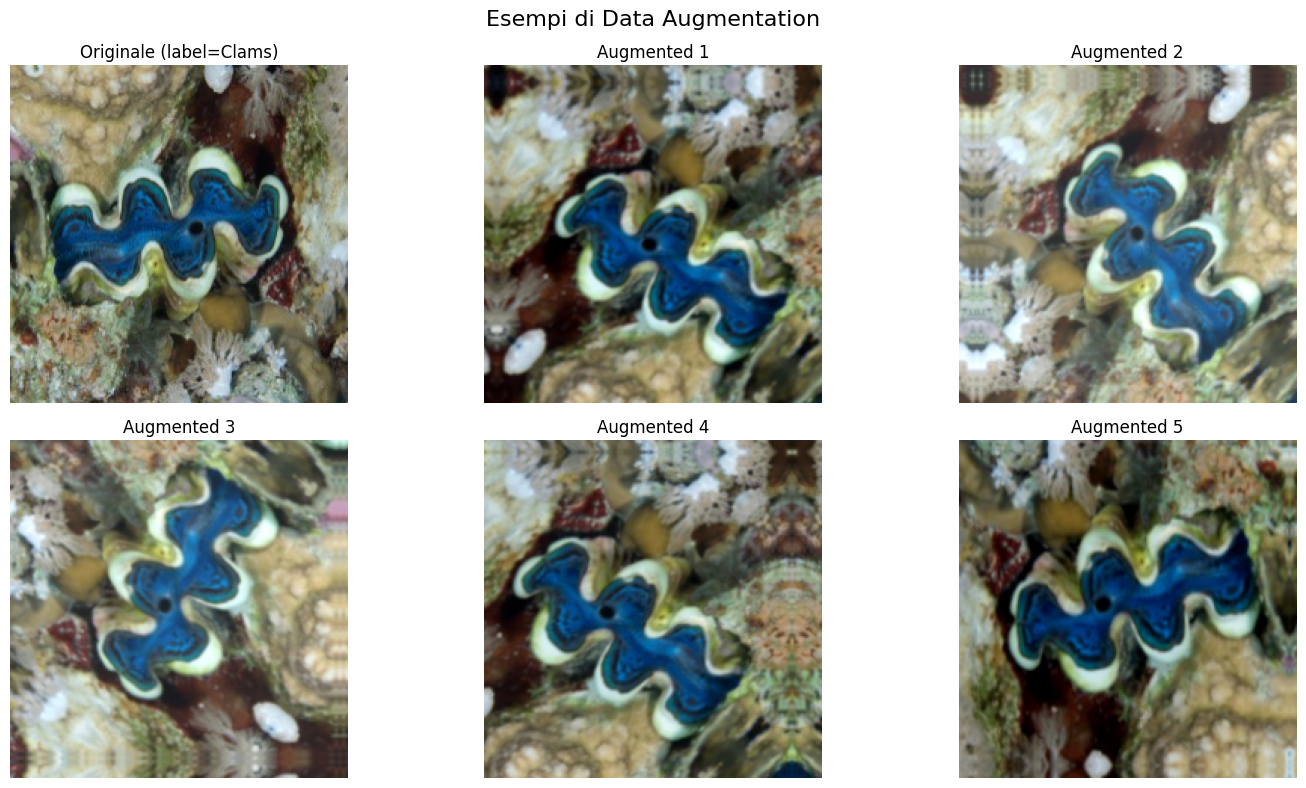

In [7]:
# Data Augmentation + esempi (come nel tuo notebook)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomFlip("vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomBrightness(0.15),
    tf.keras.layers.GaussianNoise(0.10),
])

for images, labels in train_ds.take(1):
    batch_images = images
    batch_labels = labels

original_image = batch_images[0]
label = batch_labels[0]

original_image = tf.clip_by_value(original_image, 0, 255)
original_image = tf.cast(original_image, tf.uint8)
image_batch = tf.expand_dims(original_image, axis=0)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(original_image)
plt.title(f"Originale (label={class_names[label]})")
plt.axis("off")

for i in range(1, 6):
    augmented = data_augmentation(image_batch, training=True)
    aug_img = tf.cast(tf.clip_by_value(augmented[0], 0, 255), tf.uint8)

    plt.subplot(2, 3, i + 1)
    plt.imshow(aug_img)
    plt.title(f"Augmented {i}")
    plt.axis("off")

plt.suptitle("Esempi di Data Augmentation", fontsize=16)
plt.tight_layout()
plt.show()


In [8]:
# Costruzione modello ResNet50 (Transfer Learning)

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

base_model.trainable = False  # fase 1: backbone congelato

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="ResNet50_TransferLearning")
model.summary()


Model: "ResNet50_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        47,127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,643,031 (90.19 MB)

 Trainable params: 51,223 (200.09 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [9]:
# Training fase 1 (solo head)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_phase1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase1 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_1 = model.fit(
    train_ds_RN,
    validation_data=val_ds_RN,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stopping_phase1, reduce_lr_phase1]
)


Epoch 1/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 102s 119ms/step - accuracy: 0.3167 - loss: 2.7110 - val_accuracy: 0.6471 - val_loss: 1.4253 - learning_rate: 0.0010
Epoch 2/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 80s 106ms/step - accuracy: 0.4671 - loss: 2.0376 - val_accuracy: 0.6625 - val_loss: 1.4334 - learning_rate: 0.0010
Epoch 3/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 76s 102ms/step - accuracy: 0.4846 - loss: 1.9485 - val_accuracy: 0.6618 - val_loss: 1.4018 - learning_rate: 0.0010
Epoch 4/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 80s 107ms/step - accuracy: 0.4896 - loss: 1.8972 - val_accuracy: 0.6963 - val_loss: 1.2631 - learning_rate: 0.0010
Epoch 5/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 78s 103ms/step - accuracy: 0.4979 - loss: 1.8303 - val_accuracy: 0.6544 - val_loss: 1.4638 - learning_rate: 0.0010
Epoch 6/10
680/680 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5179 - loss: 1.7724
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
680/680 ━━━━━━━━━━━━━━━━━━━━ 79s 107ms/step - accuracy: 0.517

--- Valutazione sul Test Set (Phase 1) ---
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.6921 - loss: 1.2070

Test Loss: 1.1586
Test Accuracy: 0.7064

--- Classification Report (Phase 1) ---
                 precision    recall  f1-score   support

          Clams      0.654     0.378     0.479        45
         Corals      0.528     0.776     0.628        49
          Crabs      0.836     0.979     0.902        47
        Dolphin      0.686     0.912     0.783        91
            Eel      0.386     0.750     0.510        52
           Fish      0.600     0.360     0.450        50
     Jelly Fish      0.826     0.957     0.887        94
        Lobster      0.594     0.731     0.655        52
    Nudibranchs      0.893     0.490     0.633        51
        Octopus      0.440     0.449     0.444        49
          Otter      0.957     0.917     0.936        48
        Penguin      0.806     0.568     0.667        44
        Puffers      0.750     0.457     0.568        46
 

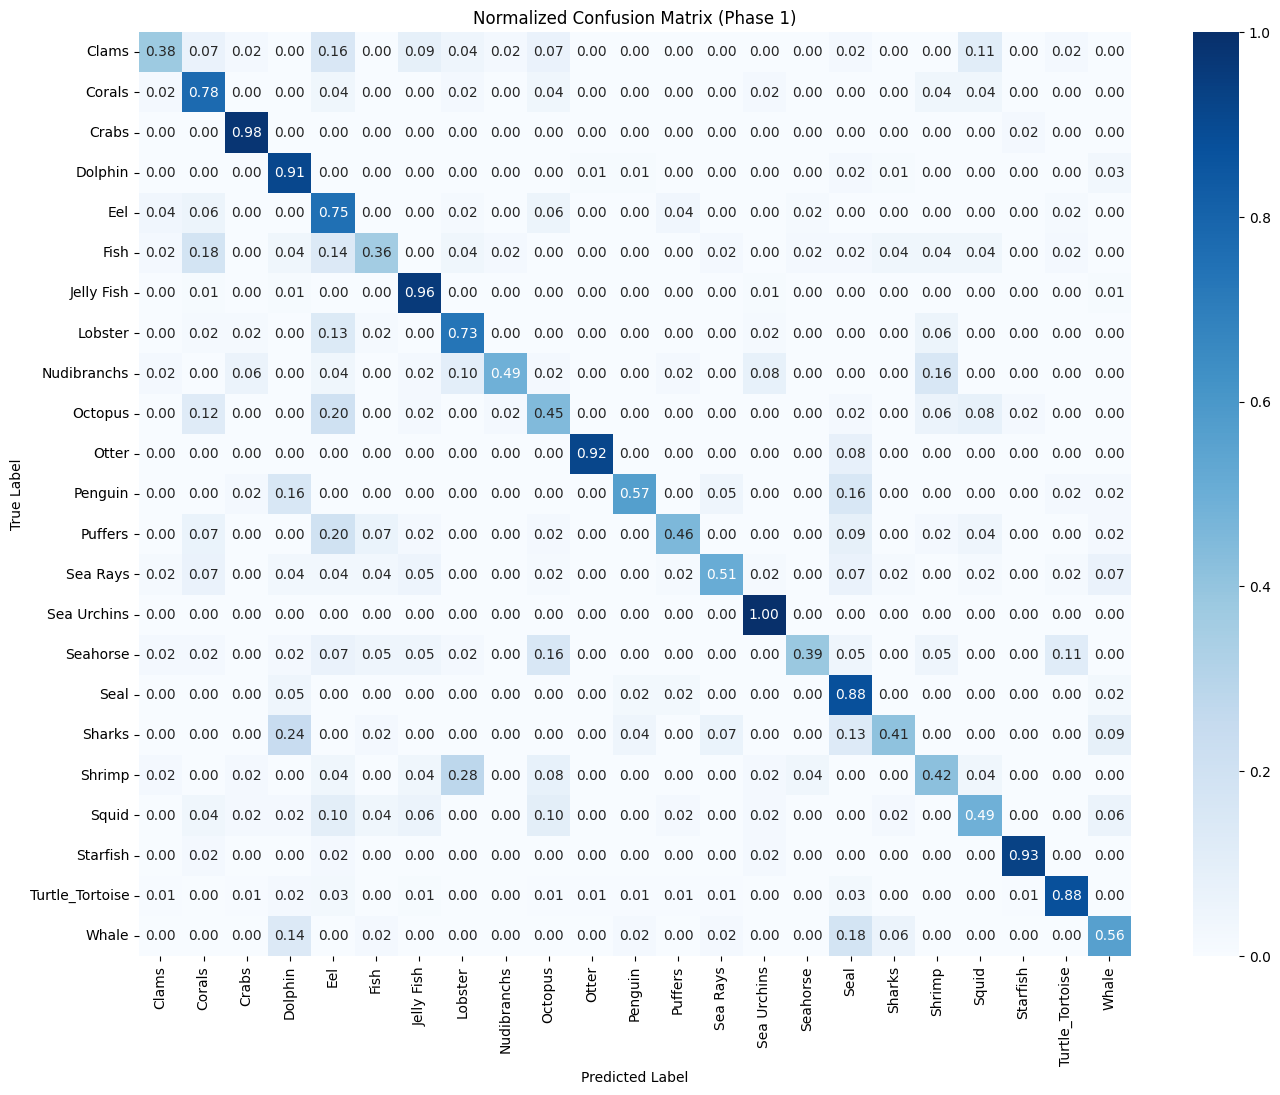

In [10]:
# Valutazione + Confusion Matrix (fase 1)

print("--- Valutazione sul Test Set (Phase 1) ---")
test_loss, test_accuracy = model.evaluate(test_ds_RN, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

y_true = []
y_pred = []

for x_batch, y_batch in test_ds_RN:
    preds = model.predict(x_batch, verbose=0)
    y_pred.append(np.argmax(preds, axis=1))
    y_true.append(y_batch.numpy())

y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

print("--- Classification Report (Phase 1) ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(16, 12))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (Phase 1)")
plt.show()


In [11]:
# Fine-tuning (sblocca ultimi N layer) + training fase 2

base_model.trainable = True

# Sblocca solo gli ultimi 10 layer del backbone
N = 10
for layer in base_model.layers[:-N]:
    layer.trainable = False

trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
total_layers = len(base_model.layers)
print(f"Trainable layers (backbone): {trainable_layers} / {total_layers}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_phase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

history_2 = model.fit(
    train_ds_RN,
    validation_data=val_ds_RN,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stopping_phase2, reduce_lr_phase2]
)


Trainable layers (backbone): 10 / 175
Epoch 1/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 95s 114ms/step - accuracy: 0.5265 - loss: 1.6593 - val_accuracy: 0.6978 - val_loss: 1.2965 - learning_rate: 5.0000e-05
Epoch 2/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 85s 114ms/step - accuracy: 0.5625 - loss: 1.5271 - val_accuracy: 0.6875 - val_loss: 1.3406 - learning_rate: 5.0000e-05
Epoch 3/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 139s 111ms/step - accuracy: 0.5740 - loss: 1.4583 - val_accuracy: 0.7176 - val_loss: 1.2315 - learning_rate: 5.0000e-05
Epoch 4/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 83s 110ms/step - accuracy: 0.5848 - loss: 1.4102 - val_accuracy: 0.7118 - val_loss: 1.2659 - learning_rate: 5.0000e-05
Epoch 5/15
680/680 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6085 - loss: 1.3095
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
680/680 ━━━━━━━━━━━━━━━━━━━━ 85s 114ms/step - accuracy: 0.6085 - loss: 1.3095 - val_accuracy: 0.7125 - val_loss: 1.2784 - learning_rate: 5.0000e-05
Epoch 6/15
680

--- Valutazione sul Test Set (Phase 2) ---
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.7271 - loss: 1.2175

Test Loss: 1.1823
Test Accuracy: 0.7447

--- Classification Report (Phase 2) ---
                 precision    recall  f1-score   support

          Clams      0.760     0.432     0.551        44
         Corals      0.607     0.694     0.648        49
          Crabs      0.880     0.978     0.926        45
        Dolphin      0.643     0.902     0.751        92
            Eel      0.562     0.720     0.632        50
           Fish      0.757     0.538     0.629        52
     Jelly Fish      0.918     0.957     0.938        94
        Lobster      0.607     0.740     0.667        50
    Nudibranchs      0.711     0.529     0.607        51
        Octopus      0.431     0.521     0.472        48
          Otter      0.976     0.870     0.920        46
        Penguin      0.882     0.682     0.769        44
        Puffers      0.800     0.750     0.774        48
 

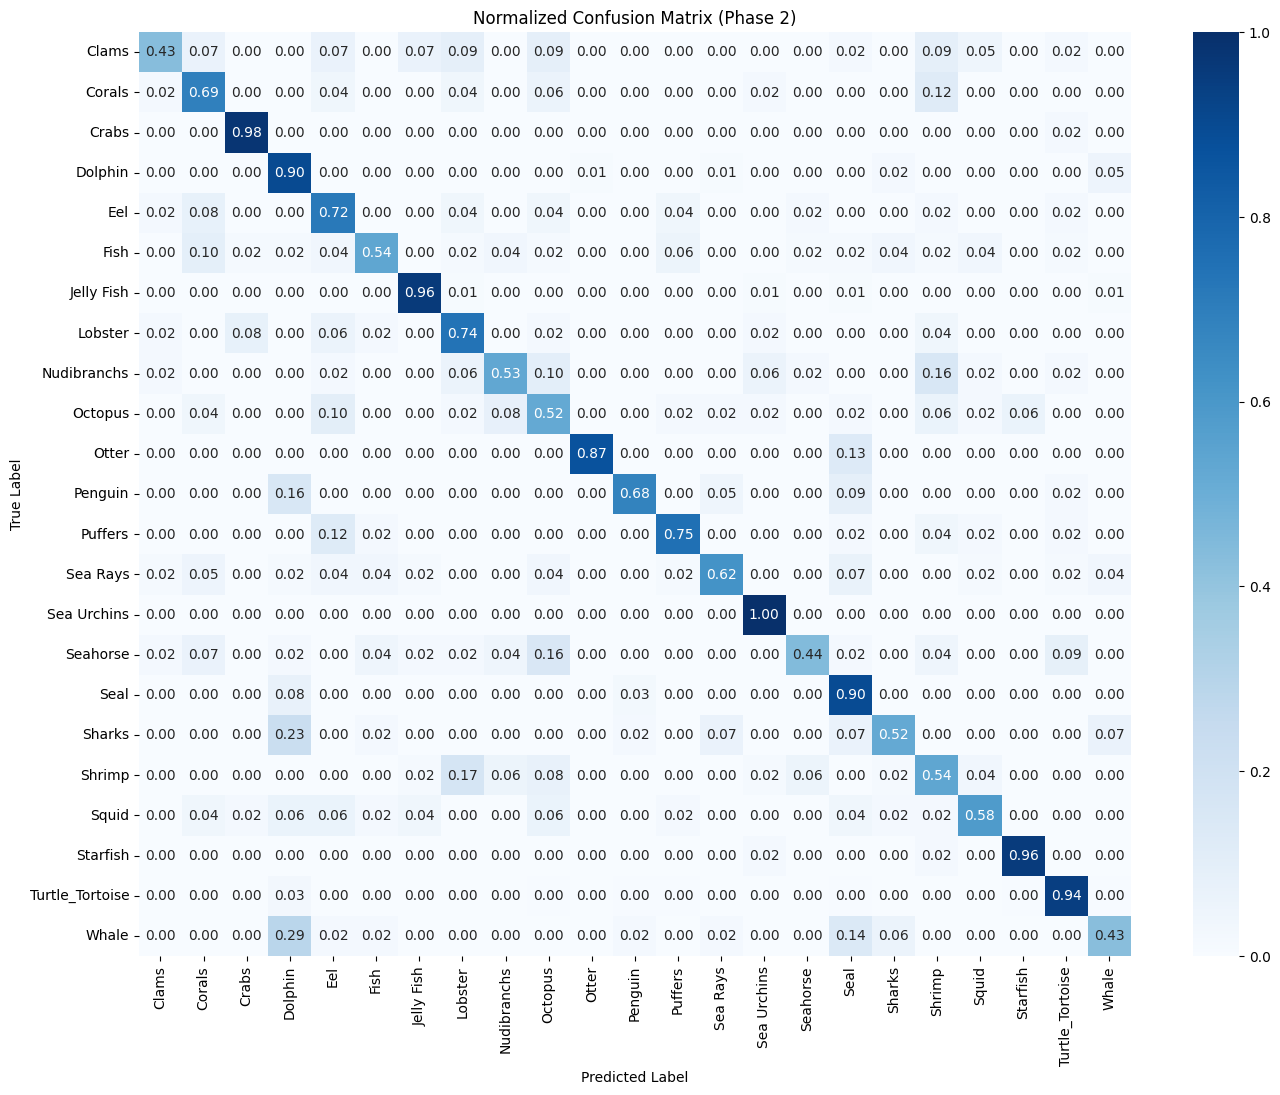

In [12]:
# Valutazione + Confusion Matrix (fase 2)

print("--- Valutazione sul Test Set (Phase 2) ---")
test_loss, test_accuracy = model.evaluate(test_ds_RN, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

y_true = []
y_pred = []

for x_batch, y_batch in test_ds_RN:
    preds = model.predict(x_batch, verbose=0)
    y_pred.append(np.argmax(preds, axis=1))
    y_true.append(y_batch.numpy())

y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

print("--- Classification Report (Phase 2) ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(16, 12))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (Phase 2)")
plt.show()
